# EDA for CRMLS Listed and Sold Data

** Names used throughout for consistency:**

- `listed_raw`, `sold_raw`: original combined datasets
- `listed`, `sold`: Residential-only working datasets
- `listed_clean`, `sold_clean`: final cleaned Week 4–5 datasets

## Setup

In [9]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Checks folder called data for datasets
# Puts final cleaned data into output folder
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Data folder:", DATA_DIR.resolve())
print("Output folder:", OUTPUT_DIR.resolve())


Data folder: /Users/junokwon/Documents/GitHub/IDXExchange-da12/data
Output folder: /Users/junokwon/Documents/GitHub/IDXExchange-da12/outputs


## Week 1 — Monthly Dataset Aggregation

In [10]:
listed_files = sorted(DATA_DIR.glob("CRMLSListing*.csv"))
sold_files = sorted(DATA_DIR.glob("CRMLSSold*.csv"))

# Fallback: if files are not inside /data, look inside parent folder.
if len(listed_files) == 0:
    listed_files = sorted(Path(".").glob("CRMLSListing*.csv"))
if len(sold_files) == 0:
    sold_files = sorted(Path(".").glob("CRMLSSold*.csv"))

print("Listed files found:", len(listed_files))
for file in listed_files:
    print(" -", file.name)

print("\nSold files found:", len(sold_files))
for file in sold_files:
    print(" -", file.name)


Listed files found: 27
 - CRMLSListing202401.csv
 - CRMLSListing202402.csv
 - CRMLSListing202403.csv
 - CRMLSListing202404.csv
 - CRMLSListing202405.csv
 - CRMLSListing202406.csv
 - CRMLSListing202407.csv
 - CRMLSListing202408.csv
 - CRMLSListing202409.csv
 - CRMLSListing202410.csv
 - CRMLSListing202411.csv
 - CRMLSListing202412.csv
 - CRMLSListing202501.csv
 - CRMLSListing202502.csv
 - CRMLSListing202503.csv
 - CRMLSListing202504.csv
 - CRMLSListing202505.csv
 - CRMLSListing202506.csv
 - CRMLSListing202507.csv
 - CRMLSListing202508.csv
 - CRMLSListing202509.csv
 - CRMLSListing202510.csv
 - CRMLSListing202511.csv
 - CRMLSListing202512.csv
 - CRMLSListing202601.csv
 - CRMLSListing202602.csv
 - CRMLSListing202603.csv

Sold files found: 27
 - CRMLSSold202401.csv
 - CRMLSSold202402.csv
 - CRMLSSold202403.csv
 - CRMLSSold202404.csv
 - CRMLSSold202405.csv
 - CRMLSSold202406.csv
 - CRMLSSold202407.csv
 - CRMLSSold202408.csv
 - CRMLSSold202409.csv
 - CRMLSSold202410.csv
 - CRMLSSold202411.csv


In [11]:
# Records each CSV's file name, # of rows and columns
def get_file_row_counts(files):
    rows = []
    for file in files:
        temp = pd.read_csv(file)
        rows.append({
            "file": file.name,
            "rows": len(temp),
            "columns": temp.shape[1]
        })
    return pd.DataFrame(rows)

# Creates summaries for each to show row x column count
listed_file_counts = get_file_row_counts(listed_files)
sold_file_counts = get_file_row_counts(sold_files)

display(listed_file_counts)
display(sold_file_counts)

print("Total listed rows before concatenation:", listed_file_counts["rows"].sum())
print("Total sold rows before concatenation:", sold_file_counts["rows"].sum())

,file,rows,columns
0,CRMLSListing202401.csv,15998,81
1,CRMLSListing202402.csv,11989,81
2,CRMLSListing202403.csv,19990,81
3,CRMLSListing202404.csv,2987,81
4,CRMLSListing202405.csv,7990,81
5,CRMLSListing202406.csv,10984,81
6,CRMLSListing202407.csv,31677,81
7,CRMLSListing202408.csv,5993,81
8,CRMLSListing202409.csv,1986,81
9,CRMLSListing202410.csv,2667,81


,file,rows,columns
0,CRMLSSold202401.csv,8985,79
1,CRMLSSold202402.csv,8985,79
2,CRMLSSold202403.csv,7990,79
3,CRMLSSold202404.csv,2992,79
4,CRMLSSold202405.csv,2992,79
5,CRMLSSold202406.csv,5990,79
6,CRMLSSold202407.csv,4993,79
7,CRMLSSold202408.csv,3992,79
8,CRMLSSold202409.csv,3992,79
9,CRMLSSold202410.csv,2992,79


Total listed rows before concatenation: 239785
Total sold rows before concatenation: 175206


In [12]:
# Combines files into one dataset
listed_raw = pd.concat([pd.read_csv(file) for file in listed_files], ignore_index=True)
sold_raw = pd.concat([pd.read_csv(file) for file in sold_files], ignore_index=True)

print("Combined listed shape:", listed_raw.shape)
print("Combined sold shape:", sold_raw.shape)

# Check rows stay the same
assert len(listed_raw) == listed_file_counts["rows"].sum()
assert len(sold_raw) == sold_file_counts["rows"].sum()

Combined listed shape: (239785, 81)
Combined sold shape: (175206, 79)


In [13]:
print("Listed PropertyType values before filtering:")
display(listed_raw["PropertyType"].value_counts(dropna=False).rename_axis("PropertyType").reset_index(name="count"))

print("Sold PropertyType values before filtering:")
display(sold_raw["PropertyType"].value_counts(dropna=False).rename_axis("PropertyType").reset_index(name="count"))

Listed PropertyType values before filtering:


,PropertyType,count
0,Residential,158229
1,ResidentialLease,40462
2,Land,16405
3,ResidentialIncome,10342
4,ManufacturedInPark,7381
5,CommercialSale,3690
6,CommercialLease,2373
7,BusinessOpportunity,903


Sold PropertyType values before filtering:


,PropertyType,count
0,Residential,102675
1,ResidentialLease,58973
2,Land,4950
3,ResidentialIncome,3610
4,ManufacturedInPark,3195
5,CommercialSale,921
6,CommercialLease,819
7,BusinessOpportunity,63


In [14]:
listed_before_residential = len(listed_raw)
sold_before_residential = len(sold_raw)

# Filters for residential
listed = listed_raw[listed_raw["PropertyType"] == "Residential"].copy()
sold = sold_raw[sold_raw["PropertyType"] == "Residential"].copy()

print("Listed rows before Residential filter:", listed_before_residential)
print("Listed rows after Residential filter:", len(listed))
print("Listed rows removed:", listed_before_residential - len(listed))

print("\nSold rows before Residential filter:", sold_before_residential)
print("Sold rows after Residential filter:", len(sold))
print("Sold rows removed:", sold_before_residential - len(sold))


Listed rows before Residential filter: 239785
Listed rows after Residential filter: 158229
Listed rows removed: 81556

Sold rows before Residential filter: 175206
Sold rows after Residential filter: 102675
Sold rows removed: 72531


In [15]:
# Saves combined residential datasets
listed.to_csv(OUTPUT_DIR / "combined_listed_residential.csv", index=False)
sold.to_csv(OUTPUT_DIR / "combined_sold_residential.csv", index=False)

print("Saved:", OUTPUT_DIR / "combined_listed_residential.csv")
print("Saved:", OUTPUT_DIR / "combined_sold_residential.csv")

Saved: outputs/combined_listed_residential.csv
Saved: outputs/combined_sold_residential.csv


## Weeks 2–3 — Dataset Structuring and Validation

In [16]:
print("Listed shape:", listed.shape)
print("Sold shape:", sold.shape)

print("\nListed columns:")
print(listed.columns.tolist())

print("\nSold columns:")
print(sold.columns.tolist())


Listed shape: (158229, 81)
Sold shape: (102675, 79)

Listed columns:
['OriginalListPrice', 'ListingKey', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus', 'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1', 'StreetNumberNumeric', 'LivingArea.1', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDat

In [17]:
display(listed.head())
display(sold.head())

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,PropertyType.1,MlsStatus,ElementarySchool,ListAgentFirstName.1,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,DaysOnMarket.1,StreetNumberNumeric,LivingArea.1,ListingId,BathroomsTotalInteger,City,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,Longitude.1,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,Latitude.1,ListPrice.1,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,ListAgentLastName.1,CloseDate.1,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,1498000.0,1156830188,NaN,NaN,Susan,Vega,33.630408,-117.694901,22871 Willard,Residential,2403.0,1498000.0,0,Realty One Group West,NaN,NaN,Susan Vega,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,NaN,1156830188,LS - Lake Forest South,NaN,Orange,Residential,ComingSoon,NaN,Susan,True,2.0,NaN,SingleFamilyResidence,0.2184,NaN,NaN,1965.0,0,22871.0,2403.0,OC26065585,3.0,Lake Forest,NaN,NaN,4.0,2026-04-09,-117.694901,NaN,NaN,NaN,2026-02-25,NaN,NaN,33.630408,1498000.0,CA,NaN,NaN,True,1.0,NaN,One,Vega,NaN,NaN,9513.0,4.0,False,2.0,Saddleback Valley Unified,92630,NaN,132.0,9513.0,NaN,22871 Willard
3,499000.0,1156818465,NaN,NaN,Keersten,Milson,33.976312,-116.522054,65352 Rolling Hills,Residential,2089.0,499000.0,0,Capitis Real Estate,NaN,NaN,Keersten Milson,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1156818465,341 - Mission Lakes,NaN,Riverside,Residential,Active,NaN,Keersten,True,2.0,NaN,SingleFamilyResidence,0.2100,Mission Lakes (34101),NaN,2020.0,0,65352.0,2089.0,JT26072467,3.0,Desert Hot Springs,NaN,NaN,4.0,2026-02-03,-116.522054,NaN,NaN,NaN,2026-02-03,NaN,NaN,33.976312,499000.0,CA,NaN,NaN,False,1.0,NaN,One,Milson,NaN,NaN,9148.0,4.0,False,2.0,Palm Springs Unified,92240,NaN,0.0,9148.0,NaN,65352 Rolling Hills
5,1195000.0,1156812825,NaN,NaN,David,Duncan,33.485133,-117.681863,25692 Paseo Colonial,Residential,1210.0,1195000.0,0,Fathom Realty Group Inc.,NaN,NaN,David Duncan,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,NaN,1156812825,DO - Del Obispo,NaN,Orange,Residential,ComingSoon,Del Obispo,David,True,4.0,NaN,SingleFamilyResidence,0.0556,Harbor Lane (HL),NaN,1973.0,0,25692.0,1210.0,PW26032885,2.0,San Juan Capistrano,NaN,NaN,3.0,2026-04-10,-117.681863,NaN,NaN,NaN,2026-02-12,0.0,NaN,33.485133,1195000.0,CA,NaN,Marco Forester,True,2.0,San Juan Hills,Two,Duncan,NaN,NaN,2420.0,0.0,False,2.0,Capistrano Unified,92675,NaN,130.0,2420.0,NaN,25692 Paseo Colonial
6,675000.0,1156808971,NaN,NaN,Mario,Garduno,32.615724,-117.045186,1221 Melrose Ave,Residential,1040.0,675000.0,0,Century 21 Affiliated,NaN,NaN,Mario Garduno,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1156808971,91911 - Chula Vista,NaN,San Diego,Residential,Active,NaN,Mario,NaN,4.0,NaN,SingleFamilyResidence,NaN,Chula Vista,NaN,1959.0,0,1221.0,1040.0,260007933SD,2.0,Chula Vista,NaN,NaN,3.0,2026-02-04,-117.045186,NaN,NaN,NaN,2026-02-04,NaN,NaN,32.615724,675000.0,CA,NaN,NaN,False,1.0,NaN,One,Garduno,NaN,NaN,NaN,NaN,False,0.0,NaN,91911,NaN,NaN,NaN,NaN,1221 Melrose Ave
7,1235000.0,1156807420,2026-04-03,1235000.0,Ariel,Belkin,34.092963,-118.337298,6737 W Hepburn,Residential,1956.0,1235000.0,0,The One Luxury Properties,The One Luxury Properties,NaN,Ariel Belkin,NaN,NaN,PF25321m,Ariel,Belkin,NaN,Monthly,NaN,1156807420,C20 - Hollywood,NaN,Los Angeles,Residential,Closed,NaN,Ariel,True,2.0,NaN,SingleFamilyRes

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName
2,OrangeCounty,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1100000.0,1155620121,2026-02-27,1100000.0,Senka,Plese,33.695943,-117.786376,14921 Groveview,Residential,1153.0,1100000.0,0,RE/MAX Connections,RE/MAX Connections,RE/MAX Connections,Senka Plese,Hannah,Song,ocplessen,Senka,Plese,NaN,NaN,NaN,1155620121,EC - El Camino Real,NaN,Orange,Closed,Greentree,True,4.0,NaN,SingleFamilyResidence,0.1148,Willows (WL),OrangeCounty,1971.0,14921.0,OC26061176,2.0,Irvine,NaN,NaN,3.0,2026-02-27,NaN,Hannah,2026-01-27,2026-01-25,NaN,NaN,CA,NaN,Venado,True,1.0,Irvine,One,NaN,5000.0,3.0,False,2.0,Irvine Unified,92604,NaN,5000.0,NaN,CRMLS,CRMLS_CRM
3,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,False,NaN,NaN,False,999000.0,1155350576,2026-02-27,938000.0,Hosh,Maha,34.187249,-118.464242,6419 Columbus Avenue,Residential,912.0,999000.0,8,EstateX inc.,EstateX inc.,EstateX inc.,Hosh Maha,Sarah,McDonald,CLW-C137047,Hosh,Maha,NaN,NaN,NaN,1155350576,VN - Van Nuys,NaN,Los Angeles,Closed,NaN,NaN,0.0,NaN,SingleFamilyResidence,0.2756,NaN,BeverlyHillsGreaterLa,1933.0,6419.0,26665349,1.0,Van Nuys,NaN,912.0,3.0,2026-02-27,NaN,Claire,2025-11-26,2025-11-18,NaN,NaN,CA,NaN,NaN,True,1.0,NaN,One,107x112,12005.0,NaN,False,NaN,NaN,91411,NaN,12005.0,NaN,CRMLS,CRMLS_CL
5,Newport,Newport,NaN,False,NaN,NaN,False,525000.0,1155192177,2026-02-24,525000.0,Dustin,Alamo,38.055464,-122.158783,255 Military W,Residential,2145.0,525000.0,0,"Alamo Pacific Realty, Inc","Alamo Pacific Realty, Inc",NaN,Dustin Alamo,NaN,NaN,NP60281,Dustin,Alamo,NaN,NaN,NaN,1155192177,NaN,NaN,Solano,Closed,NaN,NaN,0.0,NaN,SingleFamilyResidence,0.4300,NaN,Newport,1900.0,255.0,NP26055593,1.0,Benicia,NaN,NaN,4.0,2026-02-24,NaN,NaN,2026-02-08,2026-02-08,NaN,NaN,CA,NaN,NaN,False,2.0,NaN,"Two,ThreeOrMore",NaN,18730.0,4.0,False,0.0,ABC Unified,94510,0.0,18730.0,NaN,CRMLS,CRMLS_CRM
6,Mrmls,SierraNorthValley,NaN,True,NaN,NaN,False,299000.0,1155179209,2026-02-27,240000.0,Marty,Leatherman,39.734906,-121.832084,555 Vallombrosa,Residential,902.0,299000.0,0,Re/Max of Chico,NONMEMBER MRML,NaN,Marty Leatherman,NaN,NaN,nonmember,General,NONMEMBER,NaN,Monthly,NaN,1155179209,NaN,NaN,Butte,Closed,NaN,False,1.0,NaN,Condominium,0.0200,NaN,Mrmls,1973.0,555.0,SN26054377,1.0,Chico,NaN,NaN,2.0,2026-02-27,NaN,NaN,2026-01-29,2026-01-29,NaN,NaN,CA,NaN,NaN,True,1.0,NaN,One,NaN,871.0,2.0,False,1.0,Chico Unified,95926,468.0,871.0,NaN,CRMLS,CRMLS_CRM
7,CitrusValley,WestSanGabrielValley,NaN,False,NaN,NaN,False,905000.0,1155113968,2026-02-17,905000.0,Sarah,Johnson,34.179042,-118.145900,1930 N Marengo,Residential,1214.0,905000.0,0,Real Brokerage Technologies,eXp Realty of Greater Los Angeles,Real Brokerage Technologies,Sarah Johnson,PEGGY,LIM,CV49342,Vivian,Tang,NaN,NaN,NaN,1155113968,645 - Pasadena (NW),NaN,Los Angeles,Closed,Na

In [18]:
print("Listed data types:")
display(listed.dtypes.rename("dtype").reset_index().rename(columns={"index": "column"}))

print("Sold data types:")
display(sold.dtypes.rename("dtype").reset_index().rename(columns={"index": "column"}))

Listed data types:


,column,dtype
0,OriginalListPrice,float64
1,ListingKey,int64
2,CloseDate,object
3,ClosePrice,float64
4,ListAgentFirstName,object
5,ListAgentLastName,object
6,Latitude,float64
7,Longitude,float64
8,UnparsedAddress,object
9,PropertyType,object


Sold data types:


,column,dtype
0,BuyerAgentAOR,object
1,ListAgentAOR,object
2,Flooring,object
3,ViewYN,object
4,WaterfrontYN,object
5,BasementYN,object
6,PoolPrivateYN,object
7,OriginalListPrice,float64
8,ListingKey,int64
9,CloseDate,object


### Missing Value Analysis

Flag columns >90% missing values, but keep important fields

In [19]:
core_fields = [
    "CloseDate", "PurchaseContractDate", "ListingContractDate", "ContractStatusChangeDate",
    "ClosePrice", "ListPrice", "OriginalListPrice",
    "PropertyType", "PropertySubType",
    "CountyOrParish", "MLSAreaMajor", "City", "PostalCode",
    "LivingArea", "LotSizeSquareFeet", "LotSizeAcres",
    "DaysOnMarket", "BedroomsTotal", "BathroomsTotalInteger", "BathroomsTotalDecimal",
    "Latitude", "Longitude",
    "ListOfficeName", "BuyerOfficeName", "ListAgentFirstName", "ListAgentLastName"
]

missing_threshold = 0.9

# Show missing counts/percent + core field or >90% missing
def missing_report(df):
    report = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean()
    }).sort_values("missing_percent", ascending=False)
    report["above_90_percent_missing"] = report["missing_percent"] > missing_threshold
    report["core_field"] = report.index.isin(core_fields)
    return report

listed_missing_report = missing_report(listed)
sold_missing_report = missing_report(sold)

print("Listed missing value report:")
display(listed_missing_report.head(20))

print("Sold missing value report:")
display(sold_missing_report.head(20))

Listed missing value report:


,missing_count,missing_percent,above_90_percent_missing,core_field
ElementarySchoolDistrict,158229,1.000000,True,False
BusinessType,158229,1.000000,True,False
TaxAnnualAmount,158229,1.000000,True,False
MiddleOrJuniorSchoolDistrict,158229,1.000000,True,False
AboveGradeFinishedArea,158229,1.000000,True,False
TaxYear,158229,1.000000,True,False
FireplacesTotal,158229,1.000000,True,False
CoveredSpaces,158229,1.000000,True,False
BelowGradeFinishedArea,157096,0.992839,True,False
CoBuyerAgentFirstName,154577,0.976920,True,False


Sold missing value report:


,missing_count,missing_percent,above_90_percent_missing,core_field
AboveGradeFinishedArea,102675,1.000000,True,False
MiddleOrJuniorSchoolDistrict,102675,1.000000,True,False
BusinessType,102675,1.000000,True,False
ElementarySchoolDistrict,102675,1.000000,True,False
TaxYear,102675,1.000000,True,False
TaxAnnualAmount,102675,1.000000,True,False
FireplacesTotal,102675,1.000000,True,False
CoveredSpaces,102675,1.000000,True,False
WaterfrontYN,102561,0.998890,True,False
BelowGradeFinishedArea,101949,0.992929,True,False


In [20]:
#Dropping columns
listed_cols_to_drop = [
    col for col in listed.columns
    if listed_missing_report.loc[col, "above_90_percent_missing"] and col not in core_fields
]

sold_cols_to_drop = [
    col for col in sold.columns
    if sold_missing_report.loc[col, "above_90_percent_missing"] and col not in core_fields
]

print("Listed columns to drop because >90% missing and not core fields:", listed_cols_to_drop)
print("Sold columns to drop because >90% missing and not core fields:", sold_cols_to_drop)

listed = listed.drop(columns=listed_cols_to_drop)
sold = sold.drop(columns=sold_cols_to_drop)

print("Listed shape after dropping high-missing columns:", listed.shape)
print("Sold shape after dropping high-missing columns:", sold.shape)

Listed columns to drop because >90% missing and not core fields: ['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'BuilderName', 'TaxYear', 'BuildingAreaTotal', 'ElementarySchoolDistrict', 'CoBuyerAgentFirstName', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces', 'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict']
Sold columns to drop because >90% missing and not core fields: ['WaterfrontYN', 'BasementYN', 'FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'BuilderName', 'TaxYear', 'BuildingAreaTotal', 'ElementarySchoolDistrict', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces', 'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict']
Listed shape after dropping high-missing columns: (158229, 68)
Sold shape after dropping high-missing columns: (102675, 65)


### Numeric Distribution Review

Distribution review for: ClosePrice


count    1.026750e+05
mean     1.202595e+06
std      1.258104e+06
min      5.000000e+03
25%      5.900000e+05
50%      8.550000e+05
75%      1.380000e+06
90%      2.225000e+06
95%      3.025000e+06
99%      6.150000e+06
max      4.000000e+07
Name: ClosePrice, dtype: float64

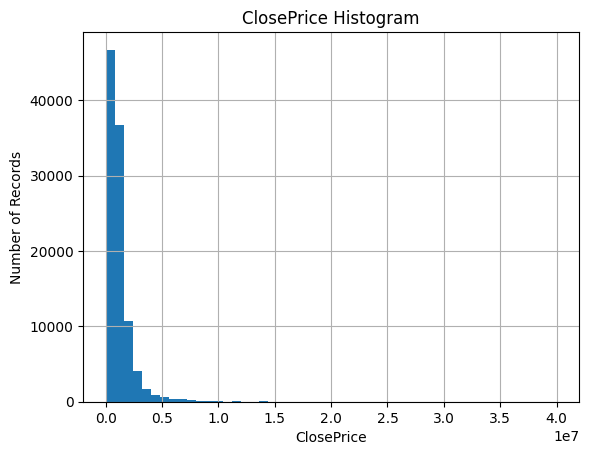

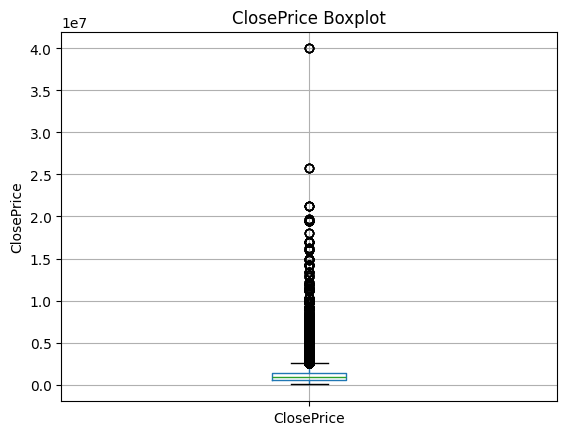

Distribution review for: ListPrice


count    1.026750e+05
mean     1.196903e+06
std      1.307993e+06
min      5.000000e+03
25%      5.959900e+05
50%      8.500000e+05
75%      1.350000e+06
90%      2.199000e+06
95%      2.995000e+06
99%      6.150000e+06
max      4.950000e+07
Name: ListPrice, dtype: float64

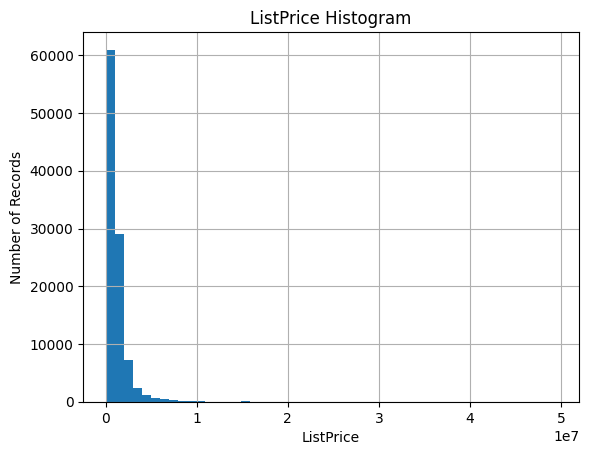

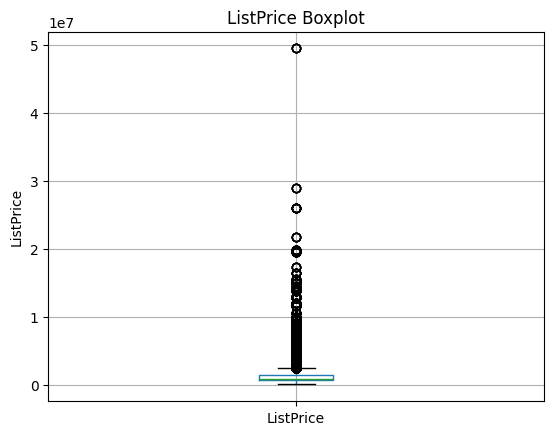

Distribution review for: OriginalListPrice


count    1.018260e+05
mean     1.607572e+06
std      1.433917e+07
min      4.090000e+02
25%      5.990000e+05
50%      8.500000e+05
75%      1.360000e+06
90%      2.198000e+06
95%      2.998000e+06
99%      6.500000e+06
max      5.898880e+08
Name: OriginalListPrice, dtype: float64

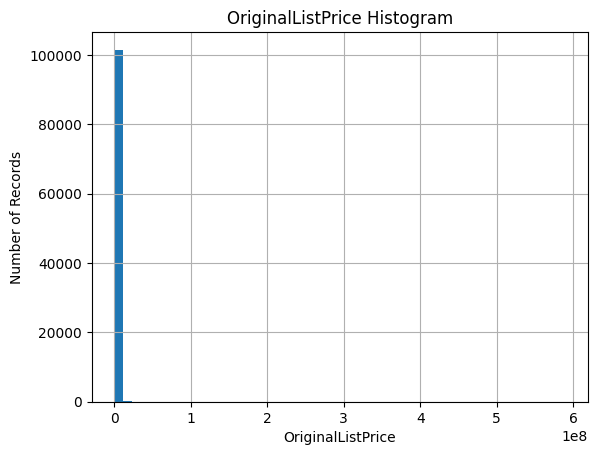

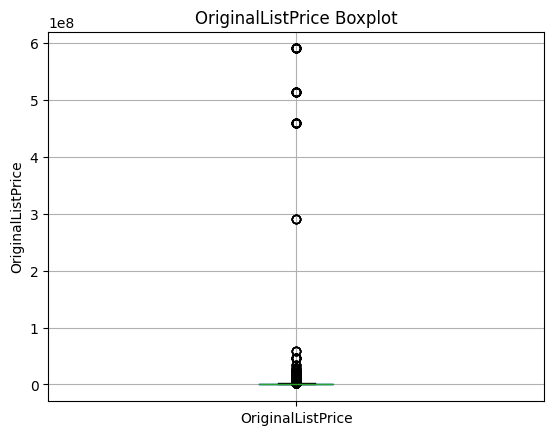

Distribution review for: LivingArea


count    102648.000000
mean       1864.774051
std         975.455871
min           0.000000
25%        1248.000000
50%        1635.000000
75%        2236.000000
90%        3006.000000
95%        3574.000000
99%        5156.000000
max       22659.000000
Name: LivingArea, dtype: float64

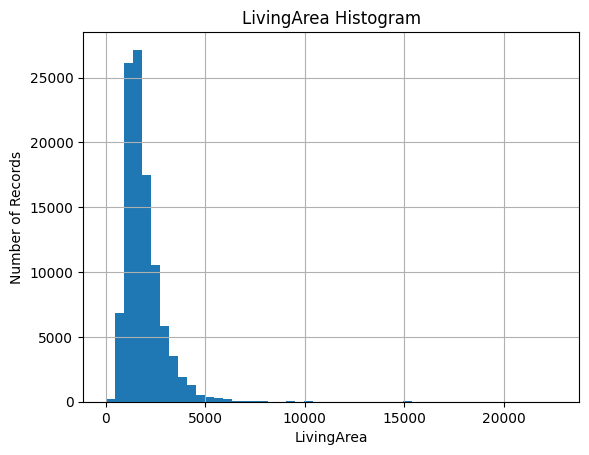

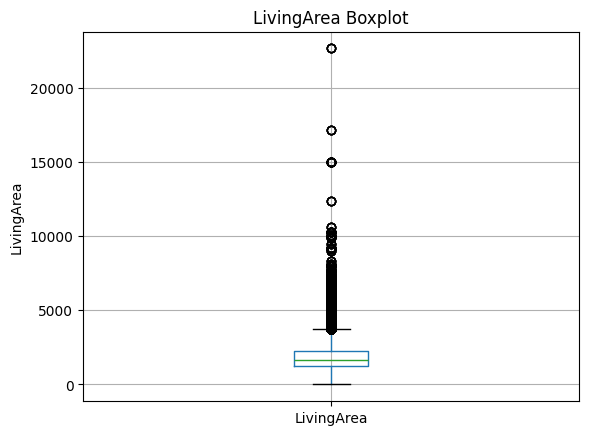

Distribution review for: LotSizeAcres


count    94020.000000
mean        17.368789
std        881.915314
min          0.000000
25%          0.119400
50%          0.165300
75%          0.270000
90%          1.050000
95%          3.000000
99%         10.825900
max      88895.000000
Name: LotSizeAcres, dtype: float64

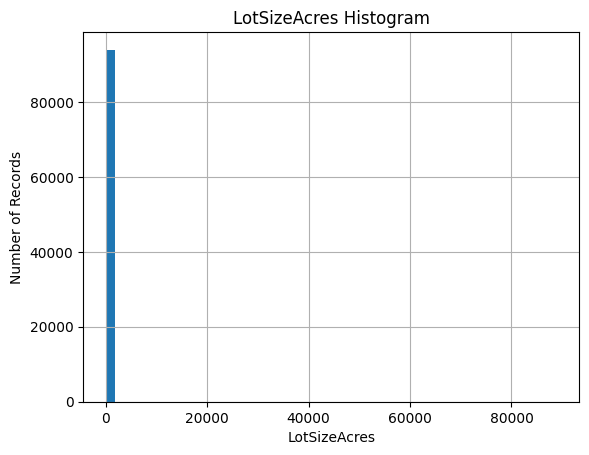

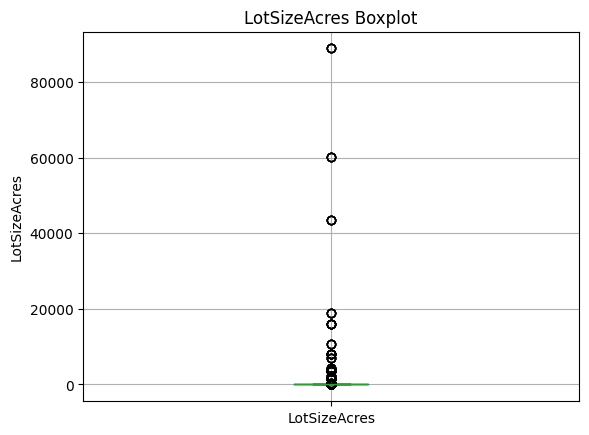

Distribution review for: BedroomsTotal


count    102670.000000
mean          3.203993
std           1.078748
min           0.000000
25%           3.000000
50%           3.000000
75%           4.000000
90%           5.000000
95%           5.000000
99%           6.000000
max          11.000000
Name: BedroomsTotal, dtype: float64

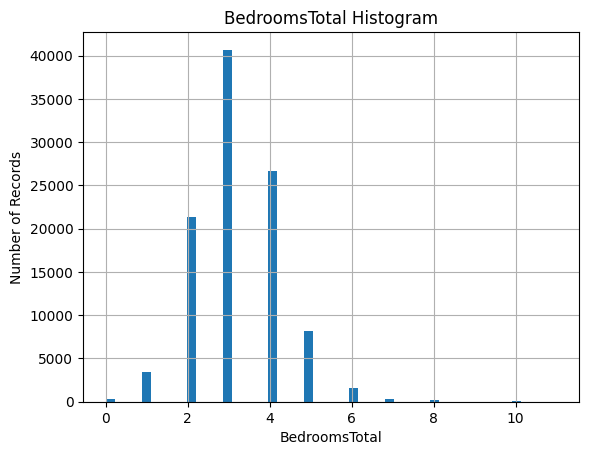

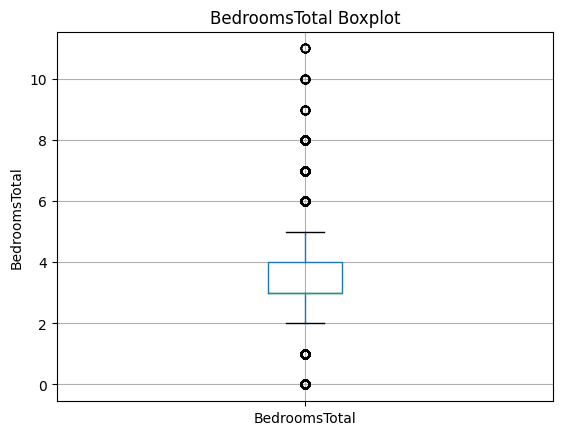

Distribution review for: BathroomsTotalInteger


count    102675.000000
mean          2.553075
std           1.080462
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
90%           4.000000
95%           4.000000
99%           6.000000
max          13.000000
Name: BathroomsTotalInteger, dtype: float64

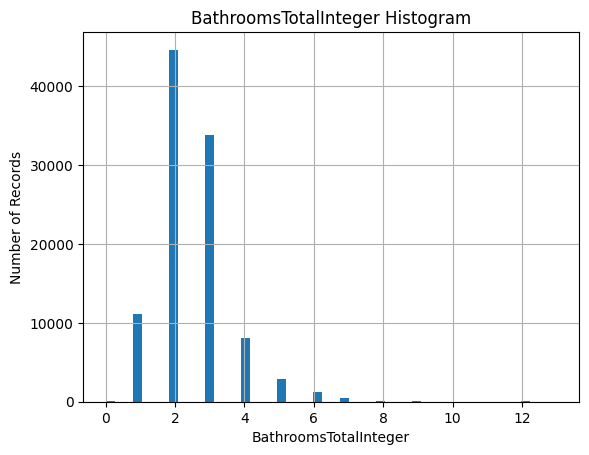

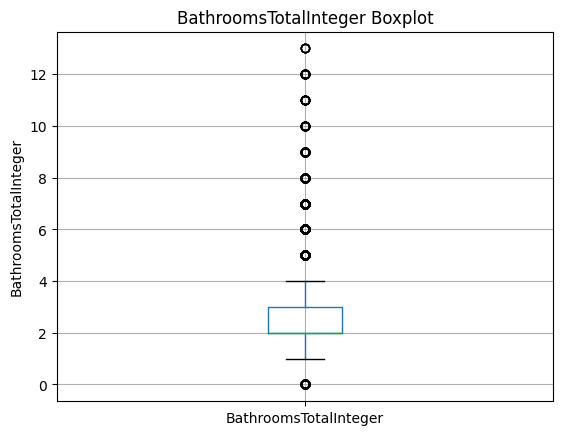

Distribution review for: DaysOnMarket


count    102675.000000
mean         31.831449
std          51.950463
min         -14.000000
25%           5.000000
50%          10.000000
75%          36.000000
90%          96.000000
95%         135.000000
99%         234.260000
max        1243.000000
Name: DaysOnMarket, dtype: float64

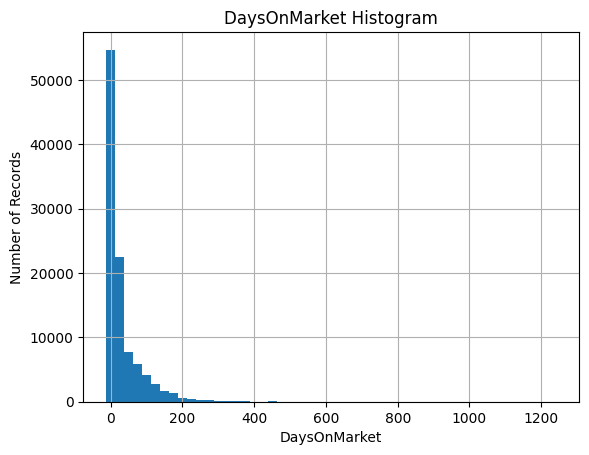

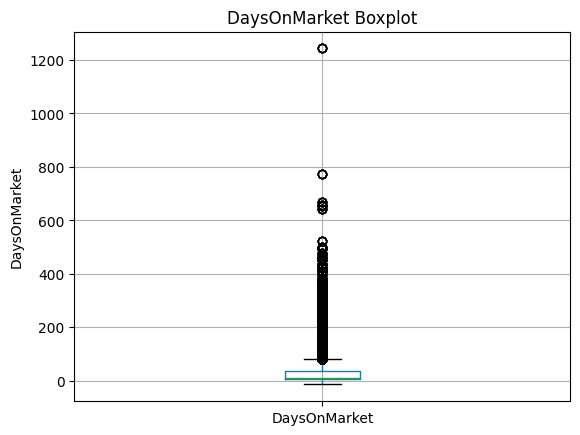

Distribution review for: YearBuilt


count    102588.000000
mean       1978.231041
std          26.575019
min        1801.000000
25%        1960.000000
50%        1979.000000
75%        1998.000000
90%        2016.000000
95%        2023.000000
99%        2025.000000
max        2026.000000
Name: YearBuilt, dtype: float64

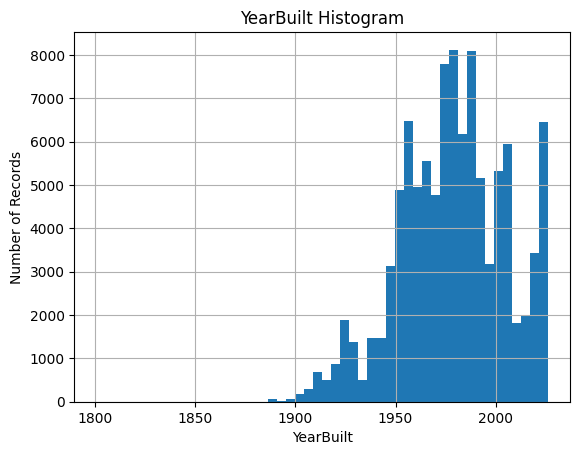

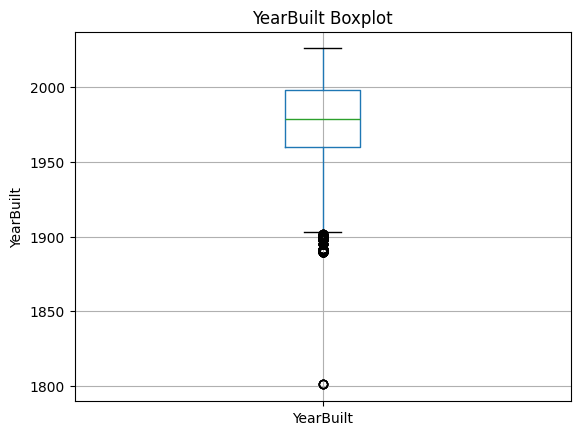

In [21]:
numeric_fields = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "LotSizeAcres",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "DaysOnMarket",
    "YearBuilt"
]

# Convert existing numeric fields before summarizing/plotting
for col in numeric_fields:
    if col in sold.columns:
        # makes sure numeric columns are numeric values
        sold[col] = pd.to_numeric(sold[col], errors="coerce")

existing_numeric_fields = [col for col in numeric_fields if col in sold.columns]

for col in existing_numeric_fields:
    print("=" * 70)
    print(f"Distribution review for: {col}")
    print("=" * 70)
    
    display(sold[col].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))
    
    #histogram
    sold[col].dropna().hist(bins=50)
    plt.title(f"{col} Histogram")
    plt.xlabel(col)
    plt.ylabel("Number of Records")
    plt.show()
    
    #boxplot
    sold.boxplot(column=col)
    plt.title(f"{col} Boxplot")
    plt.ylabel(col)
    plt.show()

### Suggested EDA Questions

In [22]:
# Residential share before filtering
residential_share_listed = (listed_raw["PropertyType"] == "Residential").mean()
residential_share_sold = (sold_raw["PropertyType"] == "Residential").mean()

print("Residential share of listed dataset:", residential_share_listed)
print("Residential share of sold dataset:", residential_share_sold)

if "ClosePrice" in sold.columns:
    print("\nMedian ClosePrice:", sold["ClosePrice"].median())
    print("Average ClosePrice:", sold["ClosePrice"].mean())

if "DaysOnMarket" in sold.columns:
    print("\nDaysOnMarket summary:")
    display(sold["DaysOnMarket"].describe())

if "ClosePrice" in sold.columns and "ListPrice" in sold.columns:
    sold["sold_above_list_flag"] = sold["ClosePrice"] > sold["ListPrice"]
    sold["sold_below_list_flag"] = sold["ClosePrice"] < sold["ListPrice"]
    print("\nPercent sold above list price:", sold["sold_above_list_flag"].mean())
    print("Percent sold below list price:", sold["sold_below_list_flag"].mean())

if "CountyOrParish" in sold.columns and "ClosePrice" in sold.columns:
    print("\nMedian ClosePrice by county:")
    display(sold.groupby("CountyOrParish")["ClosePrice"].median().sort_values(ascending=False).head(20))

# Date consistency preview for Weeks 2–3
if all(col in sold.columns for col in ["ListingContractDate", "CloseDate"]):
    preview_listing_date = pd.to_datetime(sold["ListingContractDate"], errors="coerce")
    preview_close_date = pd.to_datetime(sold["CloseDate"], errors="coerce")
    print("\nPossible listing-after-close records:", (preview_listing_date > preview_close_date).sum())


Residential share of listed dataset: 0.6598786412828158
Residential share of sold dataset: 0.5860244512174241

Median ClosePrice: 855000.0
Average ClosePrice: 1202594.8189894326

DaysOnMarket summary:


count    102675.000000
mean         31.831449
std          51.950463
min         -14.000000
25%           5.000000
50%          10.000000
75%          36.000000
max        1243.000000
Name: DaysOnMarket, dtype: float64


Percent sold above list price: 0.39590942293645
Percent sold below list price: 0.3889846603360117

Median ClosePrice by county:


CountyOrParish
San Mateo          1920000.0
Santa Clara        1600000.0
San Francisco      1265000.0
Orange             1205000.0
Alameda            1150000.0
Santa Cruz         1150000.0
Los Angeles         950000.0
San Luis Obispo     950000.0
San Diego           916500.0
Ventura             895000.0
Monterey            880000.0
Contra Costa        850000.0
El Dorado           832500.0
Mendocino           825000.0
San Benito          822000.0
Napa                766047.0
Marin               760000.0
Santa Barbara       705000.0
Nevada              620000.0
Riverside           600000.0
Name: ClosePrice, dtype: float64


Possible listing-after-close records: 51


### Mortgage Rate Enrichment

Calls FRED's `MORTGAGE30US` series, converts weekly -> monthly averages, and merges it onto both datasets using a `year_month` key.

In [23]:
fred_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"

mortgage = pd.read_csv(fred_url)

mortgage.columns = ["date", "rate_30yr_fixed"]
mortgage["date"] = pd.to_datetime(mortgage["date"])

In [24]:
listed.to_csv(OUTPUT_DIR / "listed_residential_enriched_week23.csv", index=False)
sold.to_csv(OUTPUT_DIR / "sold_residential_enriched_week23.csv", index=False)

print("Saved:", OUTPUT_DIR / "listed_residential_enriched_week23.csv")
print("Saved:", OUTPUT_DIR / "sold_residential_enriched_week23.csv")

Saved: outputs/listed_residential_enriched_week23.csv
Saved: outputs/sold_residential_enriched_week23.csv


## Weeks 4–5 — Data Cleaning and Preparation

In [25]:
# Made new copies to store cleaned versions
listed_clean = listed.copy()
sold_clean = sold.copy()

listed_rows_before_cleaning = len(listed_clean)
sold_rows_before_cleaning = len(sold_clean)

print("Listed rows before Week 4-5 cleaning:", listed_rows_before_cleaning)
print("Sold rows before Week 4-5 cleaning:", sold_rows_before_cleaning)

Listed rows before Week 4-5 cleaning: 158229
Sold rows before Week 4-5 cleaning: 102675


In [26]:
date_cols = [
    "CloseDate",
    "PurchaseContractDate",
    "ListingContractDate",
    "ContractStatusChangeDate"
]

numeric_cols = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "DaysOnMarket",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "BathroomsTotalDecimal",
    "Latitude",
    "Longitude",
    "rate_30yr_fixed"
]

def convert_existing_columns(df, date_columns, numeric_columns):
    df = df.copy()
    for col in date_columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

listed_clean = convert_existing_columns(listed_clean, date_cols, numeric_cols)
sold_clean = convert_existing_columns(sold_clean, date_cols, numeric_cols)

print("Listed dtypes after conversion:")
display(listed_clean.dtypes.rename("dtype").reset_index().rename(columns={"index": "column"}))

print("Sold dtypes after conversion:")
display(sold_clean.dtypes.rename("dtype").reset_index().rename(columns={"index": "column"}))

Listed dtypes after conversion:


,column,dtype
0,OriginalListPrice,float64
1,ListingKey,int64
2,CloseDate,datetime64[ns]
3,ClosePrice,float64
4,ListAgentFirstName,object
5,ListAgentLastName,object
6,Latitude,float64
7,Longitude,float64
8,UnparsedAddress,object
9,PropertyType,object


Sold dtypes after conversion:


,column,dtype
0,BuyerAgentAOR,object
1,ListAgentAOR,object
2,Flooring,object
3,ViewYN,object
4,PoolPrivateYN,object
5,OriginalListPrice,float64
6,ListingKey,int64
7,CloseDate,datetime64[ns]
8,ClosePrice,float64
9,ListAgentFirstName,object


In [27]:
# Remove invalid rows
def filter_invalid_numeric_values(df):
    df = df.copy()
    mask = pd.Series(True, index=df.index)
    
    # ClosePrice only exists in sold data. If it exists, it must be positive.
    if "ClosePrice" in df.columns:
        mask &= df["ClosePrice"].isna() | (df["ClosePrice"] > 0)
    
    if "LivingArea" in df.columns:
        mask &= df["LivingArea"].isna() | (df["LivingArea"] > 0)
    
    if "DaysOnMarket" in df.columns:
        mask &= df["DaysOnMarket"].isna() | (df["DaysOnMarket"] >= 0)
    
    if "BedroomsTotal" in df.columns:
        mask &= df["BedroomsTotal"].isna() | (df["BedroomsTotal"] >= 0)
    
    if "BathroomsTotalInteger" in df.columns:
        mask &= df["BathroomsTotalInteger"].isna() | (df["BathroomsTotalInteger"] >= 0)
    
    return df.loc[mask].copy()

listed_clean = filter_invalid_numeric_values(listed_clean)
sold_clean = filter_invalid_numeric_values(sold_clean)

print("Listed rows after invalid numeric filtering:", len(listed_clean))
print("Sold rows after invalid numeric filtering:", len(sold_clean))

Listed rows after invalid numeric filtering: 158102
Sold rows after invalid numeric filtering: 102645


In [28]:
def add_date_consistency_flags(df):
    df = df.copy()
    # If listing date is after close date
    if "ListingContractDate" in df.columns and "CloseDate" in df.columns:
        df["listing_after_close_flag"] = df["ListingContractDate"] > df["CloseDate"]
    else:
        df["listing_after_close_flag"] = False
    # If purchase date is after close date
    if "PurchaseContractDate" in df.columns and "CloseDate" in df.columns:
        df["purchase_after_close_flag"] = df["PurchaseContractDate"] > df["CloseDate"]
    else:
        df["purchase_after_close_flag"] = False
    # Checks if timeline order is wrong
    if all(col in df.columns for col in ["ListingContractDate", "PurchaseContractDate", "CloseDate"]):
        df["negative_timeline_flag"] = (
            (df["PurchaseContractDate"] < df["ListingContractDate"]) |
            (df["CloseDate"] < df["PurchaseContractDate"])
        )
    else:
        df["negative_timeline_flag"] = False
    
    return df

listed_clean = add_date_consistency_flags(listed_clean)
sold_clean = add_date_consistency_flags(sold_clean)

print("Listed date flag counts:")
display(listed_clean[["listing_after_close_flag", "purchase_after_close_flag", "negative_timeline_flag"]].sum())

print("Sold date flag counts:")
display(sold_clean[["listing_after_close_flag", "purchase_after_close_flag", "negative_timeline_flag"]].sum())

Listed date flag counts:


listing_after_close_flag     13
purchase_after_close_flag    19
negative_timeline_flag       83
dtype: int64

Sold date flag counts:


listing_after_close_flag      51
purchase_after_close_flag      0
negative_timeline_flag       186
dtype: int64

In [29]:
def add_geographic_flags(df):
    df = df.copy()
    # Checks if latitude/longitude is missing
    # Checks if latitude/longitude = 0
    # Checks if longitudes are incorrect by checking negative/positive values
    if "Latitude" in df.columns and "Longitude" in df.columns:
        df["missing_coords_flag"] = df["Latitude"].isna() | df["Longitude"].isna()
        df["zero_coords_flag"] = (df["Latitude"] == 0) | (df["Longitude"] == 0)
        df["positive_longitude_flag"] = df["Longitude"] > 0
        
        # Broad bounds for California-area coordinates to check if coordinates can't exist
        df["out_of_state_or_implausible_coords_flag"] = (
            (df["Latitude"] < 30) | (df["Latitude"] > 45) |
            (df["Longitude"] < -130) | (df["Longitude"] > -110)
        )
        
        df["invalid_geo_flag"] = (
            df["missing_coords_flag"] |
            df["zero_coords_flag"] |
            df["positive_longitude_flag"] |
            df["out_of_state_or_implausible_coords_flag"]
        )
    else:
        df["missing_coords_flag"] = False
        df["zero_coords_flag"] = False
        df["positive_longitude_flag"] = False
        df["out_of_state_or_implausible_coords_flag"] = False
        df["invalid_geo_flag"] = False #becomes true if any issue/flag exists
    
    return df

listed_clean = add_geographic_flags(listed_clean)
sold_clean = add_geographic_flags(sold_clean)

geo_cols = [
    "missing_coords_flag",
    "zero_coords_flag",
    "positive_longitude_flag",
    "out_of_state_or_implausible_coords_flag",
    "invalid_geo_flag"
]

print("Listed geographic flag counts:")
display(listed_clean[geo_cols].sum())

print("Sold geographic flag counts:")
display(sold_clean[geo_cols].sum())

Listed geographic flag counts:


missing_coords_flag                        1524
zero_coords_flag                             51
positive_longitude_flag                      87
out_of_state_or_implausible_coords_flag     156
invalid_geo_flag                           1680
dtype: int64

Sold geographic flag counts:


missing_coords_flag                        785
zero_coords_flag                            15
positive_longitude_flag                     18
out_of_state_or_implausible_coords_flag     33
invalid_geo_flag                           818
dtype: int64

In [30]:
# Fill selected non-critical numeric missing values with medians.
fill_with_median_cols = ["BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket"]

def fill_selected_medians(df, columns):
    df = df.copy()
    for col in columns:
        if col in df.columns and df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())
    return df

listed_clean = fill_selected_medians(listed_clean, fill_with_median_cols)
sold_clean = fill_selected_medians(sold_clean, fill_with_median_cols)

print("Filled selected numeric missing values with column medians.")

Filled selected numeric missing values with column medians.


In [31]:
print("Final week 4-5 data quality summary")
print("=" * 50)

print("Listed rows before cleaning:", listed_rows_before_cleaning)
print("Listed rows after cleaning:", len(listed_clean))
print("Listed rows removed:", listed_rows_before_cleaning - len(listed_clean))

print("\nSold rows before cleaning:", sold_rows_before_cleaning)
print("Sold rows after cleaning:", len(sold_clean))
print("Sold rows removed:", sold_rows_before_cleaning - len(sold_clean))

print("\nTop missing columns in listed_clean:")
display(listed_clean.isna().sum().sort_values(ascending=False).head(10))

print("Top missing columns in sold_clean:")
display(sold_clean.isna().sum().sort_values(ascending=False).head(10))

print("\nSold date flag counts:")
display(sold_clean[["listing_after_close_flag", "purchase_after_close_flag", "negative_timeline_flag"]].sum())

print("Sold geographic flag counts:")
display(sold_clean[geo_cols].sum())


Final week 4-5 data quality summary
Listed rows before cleaning: 158229
Listed rows after cleaning: 158102
Listed rows removed: 127

Sold rows before cleaning: 102675
Sold rows after cleaning: 102645
Sold rows removed: 30

Top missing columns in listed_clean:


ElementarySchool        136506
MiddleOrJuniorSchool    136413
HighSchool              130023
BuyerOfficeAOR          125917
ClosePrice              124540
BuyerOfficeName.1       122386
BuyerOfficeName         122386
BuyerAgentFirstName     121968
BuyerAgentMlsId         121826
BuyerAgentLastName      121801
dtype: int64

Top missing columns in sold_clean:


CoBuyerAgentFirstName      91927
MiddleOrJuniorSchool       90258
ElementarySchool           90257
HighSchool                 86845
CoListAgentFirstName       78794
CoListAgentLastName        78695
CoListOfficeName           78677
SubdivisionName            60875
AssociationFeeFrequency    59220
MainLevelBedrooms          46961
dtype: int64


Sold date flag counts:


listing_after_close_flag      51
purchase_after_close_flag      0
negative_timeline_flag       186
dtype: int64

Sold geographic flag counts:


missing_coords_flag                        785
zero_coords_flag                            15
positive_longitude_flag                     18
out_of_state_or_implausible_coords_flag     33
invalid_geo_flag                           818
dtype: int64

In [32]:
# Saves cleaned datasets to output folder
listed_clean.to_csv(OUTPUT_DIR / "cleaned_listed_week45.csv", index=False)
sold_clean.to_csv(OUTPUT_DIR / "cleaned_sold_week45.csv", index=False)

print("Saved:", OUTPUT_DIR / "cleaned_listed_week45.csv")
print("Saved:", OUTPUT_DIR / "cleaned_sold_week45.csv")

Saved: outputs/cleaned_listed_week45.csv
Saved: outputs/cleaned_sold_week45.csv


## Feature Engineering and Market Metrics
1. Price Ratio = ClosePrice / OriginalListPrice
2. Price Per Sq Ft = ClosePrice / Living Area
3. Days on Market = DaysOnMarket(raw field)
4. Close to Original List Ratio = ClosePrice / OriginalListPrice
5. Listing to Contract Days = PurchaseContractDate - ListingContractDate
6. Contract to Close Days = CloseDate - PurchaseContractDate

In [33]:
# Making sure dates are in datetime format
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'])
sold['PurchaseContractDate'] = pd.to_datetime(sold['PurchaseContractDate'])
sold['ListingContractDate'] = pd.to_datetime(sold['ListingContractDate'])

In [34]:
# Ratios
sold['price_ratio'] = sold['ClosePrice'] / sold['OriginalListPrice']
sold['close_to_original_list_ratio'] = sold['ClosePrice'] / sold['OriginalListPrice']
sold['ppsf'] = sold['ClosePrice'] / sold['LivingArea'] # ppsf = Price Per Sq Ft

In [35]:
# Time Features
sold['yr'] = sold['CloseDate'].dt.year
sold['month'] = sold['CloseDate'].dt.month
sold['yrmo'] = sold['CloseDate'].dt.to_period('M')

In [36]:
# Timeline Metrics
sold['listing_to_contract_days'] = (sold['PurchaseContractDate'] - sold['ListingContractDate']).dt.days
sold['contract_to_close_days'] = (sold['CloseDate'] - sold['PurchaseContractDate']).dt.days

## Segment Analysis/Summary
1. PropertyType and PropertySubType
2. CountyOrParish and MLSAreaMajor
3. ListOfficeName and BuyerOfficeName

In [37]:
# By county
county_summary = sold.groupby("CountyOrParish").agg({'ClosePrice' : ['median',  'mean'],
                                                     'ppsf': 'median',
                                                     'DaysOnMarket': 'mean'})

In [38]:
# By Property Type
property_summary = sold.groupby('PropertyType').agg({'ClosePrice': 'median',
                                                     'ppsf': 'median'})

In [39]:
print(
    sold[
        ['ClosePrice',
          'OriginalListPrice',
          'price_ratio',
          'ppsf',
          'listing_to_contract_days'
          ]
        ].head()
)

   ClosePrice  OriginalListPrice  price_ratio         ppsf  \
2   1100000.0          1100000.0     1.000000   954.032958   
3    938000.0           999000.0     0.938939  1028.508772   
5    525000.0           525000.0     1.000000   244.755245   
6    240000.0           299000.0     0.802676   266.075388   
7    905000.0           905000.0     1.000000   745.469522   

   listing_to_contract_days  
2                       2.0  
3                       8.0  
5                       0.0  
6                       0.0  
7                       0.0  


In [40]:
# Save engineered dataset
sold.to_csv(
    'sold_engineered.csv',
    index=False
)

## Outlier Detection + Data Quality

In [41]:
# IQR Function
def add_iqr_flag(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    flag_col = f'{column}_outlier_flag'
    df[flag_col] = ((df[column] < lower) | (df[column] > upper))
    return df

In [42]:
sold = add_iqr_flag(sold, 'ClosePrice')
sold = add_iqr_flag(sold, 'LivingArea')
sold = add_iqr_flag(sold, 'DaysOnMarket')

In [44]:
# Keeping original + filtered dataset
sold.to_csv(
    'sold_flagged.csv',
    index=False
)
sold_clean = sold[
    (~sold['ClosePrice_outlier_flag']) &
    (~sold['LivingArea_outlier_flag']) &
    (~sold['DaysOnMarket_outlier_flag'])
]
sold_clean.to_csv(
    'sold_filtered.csv',
    index=False
)

In [45]:
# Comparisons
print("Original rows:", len(sold))
print("Filtered rows:", len(sold_clean))
print("Original median price:", sold['ClosePrice'].median())
print("Filtered median price:", sold_clean['ClosePrice'].median())

Original rows: 102675
Filtered rows: 81986
Original median price: 855000.0
Filtered median price: 823000.0
